In [ ]:
%pip install torch torchvision torchaudio transformers

import os
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn import functional as F

from transformer_blocks import Block

from torch import nn
from torch.utils.data import Dataset, DataLoader

In [4]:
with open("../data/corpus.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

print(text[:500])

lari merupakan salah satu cabang olahraga yang paling tua dan paling populer di dunia. aktivitas ini telah dilakukan manusia sejak zaman prasejarah sebagai bagian dari kebutuhan untuk berburu, berpindah tempat, dan bertahan hidup. seiring perkembangan peradaban, lari tidak lagi hanya menjadi sarana untuk memenuhi kebutuhan hidup, tetapi juga berkembang menjadi aktivitas olahraga, rekreasi, dan kompetisi. saat ini, lari menjadi salah satu olahraga yang dapat dilakukan oleh hampir semua orang kare


In [5]:
#Preprocessing text

text = re.sub(r"[^\w\s]", "", text)
text = re.sub(r"\s+", " ", text)

tokens = text.split()

print("Jumlah token :", len(tokens))

Jumlah token : 2599


In [6]:
#Vocabulary
vocab = sorted(set(tokens))

stoi = {word:i for i,word in enumerate(vocab)}
itos = {i:word for word,i in stoi.items()}

vocab_size = len(vocab)

print("Vocabulary Size :", vocab_size)

Vocabulary Size : 700


In [7]:
#Encoding 
ids = [stoi[word] for word in tokens]

data = torch.tensor(
    ids,
    dtype=torch.long
)

print(data[:20])

tensor([319, 438, 567, 571, 101, 463, 694, 474, 680, 114, 474, 533, 127, 168,
         21, 214, 646, 142, 342, 583])


In [8]:
block_size = 8

embedding_dim = 64

n_heads = 4

n_layers = 4

lr = 1e-3

epochs = 3000

In [9]:
def get_batch(batch_size=16):

    ix = torch.randint(
        len(data)-block_size,
        (batch_size,)
    )

    x = torch.stack(
        [data[i:i+block_size] for i in ix]
    )

    y = torch.stack(
        [data[i+1:i+block_size+1] for i in ix]
    )

    return x,y

In [10]:
class TinyGPT(nn.Module):

    def __init__(self):

        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embedding_dim
        )

        self.blocks = nn.Sequential(
            *[
                Block(
                    embedding_dim,
                    block_size,
                    n_heads
                )
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(
            embedding_dim
        )

        self.head = nn.Linear(
            embedding_dim,
            vocab_size
        )

    def forward(
        self,
        idx,
        targets=None
    ):

        B,T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos_emb = self.position_embedding(
            torch.arange(T)
        )

        x = tok_emb + pos_emb

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.head(x)

        loss = None

        if targets is not None:

            B,T,C = logits.shape

            loss = F.cross_entropy(
                logits.view(B*T,C),
                targets.view(B*T)
            )

        return logits,loss

    def generate(
        self,
        idx,
        max_new_tokens
    ):

        for _ in range(max_new_tokens):

            idx_cond = idx[:,-block_size:]

            logits,_ = self(idx_cond)

            logits = logits[:,-1,:]

            probs = F.softmax(
                logits,
                dim=-1
            )

            next_idx = torch.multinomial(
                probs,
                1
            )

            idx = torch.cat(
                (idx,next_idx),
                dim=1
            )

        return idx

In [11]:
import torch.nn.functional as F

class Block(nn.Module):
    def __init__(self, embed_dim, block_size, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )

    def forward(self, x):
        # x: (B, T, E)
        x_res = self.ln1(x)
        attn_out, _ = self.attn(x_res, x_res, x_res, need_weights=False)
        x = x + attn_out
        x_res = self.ln2(x)
        x = x + self.mlp(x_res)
        return x

model = TinyGPT()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr
)

losses = []

for step in range(epochs):

    xb,yb = get_batch()

    logits,loss = model(
        xb,
        yb
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if step % 100 == 0:

        print(
            f"Step {step}, Loss = {loss.item():.4f}"
        )

Step 0, Loss = 6.7277
Step 100, Loss = 5.1644
Step 200, Loss = 2.6948
Step 300, Loss = 1.6790
Step 400, Loss = 1.0475
Step 500, Loss = 0.5881
Step 600, Loss = 0.3398
Step 700, Loss = 0.2805
Step 800, Loss = 0.2690
Step 900, Loss = 0.1388
Step 1000, Loss = 0.1791
Step 1100, Loss = 0.1454
Step 1200, Loss = 0.0968
Step 1300, Loss = 0.0989
Step 1400, Loss = 0.0853
Step 1500, Loss = 0.0249
Step 1600, Loss = 0.0508
Step 1700, Loss = 0.0162
Step 1800, Loss = 0.0223
Step 1900, Loss = 0.0101
Step 2000, Loss = 0.0177
Step 2100, Loss = 0.0057
Step 2200, Loss = 0.0063
Step 2300, Loss = 0.0056
Step 2400, Loss = 0.0053
Step 2500, Loss = 0.0055
Step 2600, Loss = 0.0044
Step 2700, Loss = 0.0037
Step 2800, Loss = 0.0027
Step 2900, Loss = 0.0025


In [12]:
os.makedirs("../models/word", exist_ok=True)

torch.save(
    model.state_dict(),
    "../models/word/model.pth"
)

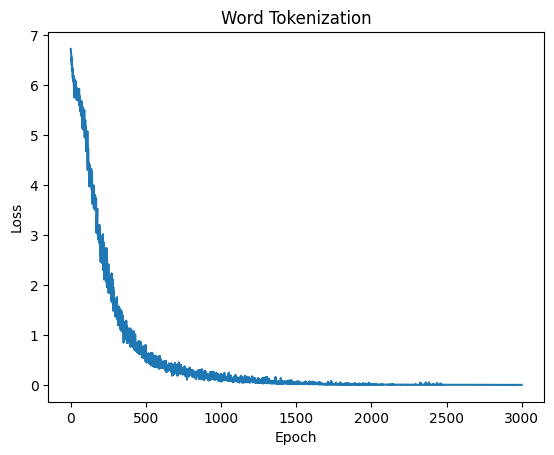

In [13]:
plt.plot(losses)
plt.title("Word Tokenization")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig(
    "../results/plots/word_loss.png"
)

plt.show()

In [15]:
prompt = "lari merupakan"

context = torch.tensor(
    [[stoi.get(word, 0) for word in prompt.split()]],
    dtype=torch.long
)

out = model.generate(
    context,
    max_new_tokens=50
)

generated_words = [
    itos[idx]
    for idx in out[0].tolist()
]

generated_text = " ".join(
    generated_words
)

print(generated_text)

lari merupakan sisi sisi lari lari merupakan salah satu ajang yang sering terjadi terutama seperti 5000 meter memperoleh pengetahuan kaki hubungan mental dari sisi dalam perlindungan memiliki memberikan kesempatan latihan aplikasi pelari jarak jauh memanfaatkan lemak sebagai salah satu sumber energi selama berlari dalam waktu yang lama oleh karena itu konsumsi lemak


KeyError: 'lari'

In [30]:
def generate_text(
    start_text,
    max_words=30
):

    words = start_text.lower().split()

    for _ in range(max_words):

        context = words[-BLOCK_SIZE:]

        context_ids = [
            stoi.get(w,0)
            for w in context
        ]

        while len(context_ids) < BLOCK_SIZE:
            context_ids.insert(0,0)

        x = torch.tensor(
            [context_ids]
        )

        pred = model(x)

        idx = torch.argmax(
            pred,
            dim=1
        ).item()

        words.append(
            itos[idx]
        )

    return " ".join(words)

In [31]:
print(
    generate_text(
        "lari merupakan"
    )
)

TypeError: argmax(): argument 'input' (position 1) must be Tensor, not tuple